# EEGNet: Continuous Trajectory Decoding for Robotic Arm Control

This notebook implements a complete Deep Learning pipeline to translate raw ECoG brain signals into continuous finger flexion trajectories.

**Key Engineering Decisions:**
1. **Architecture:** We use a custom `EEGNet` model. Because we are deploying this to a physical microcontroller for real-time robotic arm actuation, we require a model with low inference latency. EEGNet uses lightweight 1D/2D temporal and spatial convolutions instead of heavy Recurrent layers (like LSTMs).
2. **Metric:** Model performance is evaluated using the Pearson Correlation Coefficient ($r$). A score above 0.40 indicates successful intent extraction, and anything approaching 0.60 is excellent for stable robotic control.


In [ ]:
%reset -f

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import scipy.signal as signal
import gc
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
X_train_all = np.load("X_train_all.npy")
y_train_all = np.load("y_train_all.npy")
print(f"X: {X_train_all.shape}, Y: {y_train_all.shape}")

X: (300000, 45), Y: (300000, 5)


## 1. Data Preparation & Scaling
Neural networks converge much faster when input features operate on the same numerical scale. We use standard Z-score normalization so that every physical electrode channel has a mean of 0 and a standard deviation of ~1.

In [ ]:
# Standardize the data so all 45 brain channels operate on the exact same scale.
# This makes it much easier for the neural network to find patterns without
# getting distracted by channels that naturally have higher electrical voltages.
scaler = StandardScaler()
X_train_all = scaler.fit_transform(X_train_all)

print(f"After Scaling: ")
print(f" Mean(should be ~0): {X_train_all.mean(axis=0)[:5].round(4)}")
print(f" std(should be ~1): {X_train_all.std(axis=0)[:5].round(4)}")


After Scaling: 
 Mean(should be ~0): [ 0.  0. -0.  0. -0.]
 std(should be ~1): [1. 1. 1. 1. 1.]


## 2. Windowing Strategy (Raw Signals)
Unlike classical Machine Learning baselines (like Ridge Regression) that require manual feature extraction (mean, variance, etc.), Convolutional Neural Networks learn their own features.

We slice the continuous timeline into **400ms windows** (100 samples at 250 Hz) and feed the raw signal directly into the network.

In [ ]:
# We slice the continuous brainwave timeline into small, manageable chunks.
# At a 250 Hz sampling rate, 100 samples equals exactly 400 milliseconds.
# This gives the model a 400ms "glimpse" of brain activity to predict the finger movement.
WINDOW_SIZE = 100 # 100 Samples at 250 Hz = 400ms window

def create_raw_windows_batched(X,y, Window_size = 25, batch_size = 50000):
  """
    Creates raw windows for LSTM — keeps the actual signal, no feature extraction.
    Each window shape: (25 timesteps, 45 channels)

  """
  n_samples = len(X) - Window_size
  all_window = []
  all_label = []

  for start_val in range(0, n_samples, batch_size):
    end_val = min(start_val + batch_size, n_samples)
    batch_window = []
    batch_label = []

    for i in range(start_val, end_val):
      batch_window.append(X[i: i+Window_size])
      batch_label.append(y[i + Window_size])

    if len(batch_window) > 0:
      all_window.append(np.array(batch_window, dtype = np.float32))
      all_label.append(y[Window_size + start_val : Window_size + end_val])
    print(f" Processed {end_val:,}/ {n_samples: ,} ({100 * end_val / n_samples:.1f}%)", end = "\r")

  print(" Done!" + " " * 50)
  return np.concatenate(all_window), np.concatenate(all_label).astype(np.float32)

print("Creating raw windows...")
X_windows, y_labels = create_raw_windows_batched(X_train_all, y_train_all, Window_size= WINDOW_SIZE)


y_label = np.delete(y_labels, 3, axis = 1)


del X_train_all, y_train_all
gc.collect()

print(f"\nX_Window: {X_windows.shape} --> (Smaples, 25 timesteps, 45 channels)")
print(f"y_label: {y_labels.shape} --> (samples, fingers)")

Creating raw windows...
 Done!                                                  

X_Window: (299900, 100, 45) --> (Smaples, 25 timesteps, 45 channels)
y_label: (299900, 5) --> (samples, fingers)


## 3. OPTIMIZATION: Smoothing the Target Labels

* **The Problem:** The raw finger data (`y_labels`) recorded by the glove has tiny sensor glitches and static. If we don't fix this, the model gets confused trying to predict jerky, impossible finger movements.
* **The Fix:** Real fingers move smoothly. We used a Moving Average filter to smooth out the labels. This gives the model a clean, natural physical curve to learn.

> **Why we skipped Bandpass Filtering:** > We deliberately did *not* apply a standard 8-100Hz Bandpass Filter to the input brainwaves (`X`). While common in other projects, it actually made our model perform worse! Continuous movement tracking relies heavily on very slow brainwaves (under 5 Hz) called Local Motor Potentials. Standard filtering accidentally deletes these crucial signals.

In [ ]:
# THE PHYSICS FIX: TARGET SMOOTHING: -

# Real fingers move in smooth physical curves, but our data glove sensors have microscopic jitters.
# This moving average filter smooths out the target labels (y).
# If we don't do this, the model wastes processing power trying to predict impossible, jerky finger teleportations!
def moving_smooth(data, window_size = 5):
  smoothed_data = np.copy(data)
  for i in range(data.shape[1]):
    padded = np.pad(data[:, i], (window_size // 2, window_size // 2), mode = "edge")
    smoothed_data[:, i] = np.convolve(padded, np.ones(window_size) / window_size, mode = "valid")
  return smoothed_data

# Execute the smoothing right here in Cell 6, BEFORE PyTorch packs the data!
y_labels = moving_smooth(y_labels, window_size=5)
print("Targets successfully smoothed!")

Targets successfully smoothed!


## 4. PyTorch Dataset & Batching
We wrap our data in a custom PyTorch Dataset.

**Crucial Fix (`drop_last=True`):** The total number of validation windows does not divide perfectly by our Batch Size of 64. This leaves a tiny "leftover" batch at the very end of the dataset, which causes shape mismatch errors during loss calculation. Dropping these last few irregular samples fixes the crash without impacting our final performance metrics.

In [ ]:
class ECoGDataset(Dataset):
  """
      Wraps our numpy arrays so PyTorch can use them.
      Think of it like a container — PyTorch reaches in and grabs one sample at a time.

  """
  def __init__(self, X, y):
    self.X = torch.tensor(X, dtype = torch.float32)
    self.y = torch.tensor(y, dtype = torch.float32)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

full_dataset = ECoGDataset(X_windows, y_labels)

num_samples = len(X_windows)
indices = np.random.permutation(num_samples)
split = int(0.8 * num_samples)

train_indices = indices[:split]
val_indices = indices[split:]

train_sampler = SubsetRandomSampler(train_indices)
val_sampler = SubsetRandomSampler(val_indices)

BATCH_SIZE = 64

train_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, sampler=train_sampler)

# drop_last=True prevents shape mismatch crashes on the final incomplete batch
val_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, sampler=val_sampler, drop_last=True)

print(f"\nOne Batch: ")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")


One Batch: 
Train batches: 3749
Val batches: 937


## 5. EEGNet Architecture & Training Pipeline
We use Adam optimization and a `ReduceLROnPlateau` scheduler to automatically drop the learning rate if the validation loss stops improving.

**Memory Management:** Inside the training loop, we specifically use `loss.item()` to extract the loss as a simple float. If we accidentally appended the raw `loss` tensor, PyTorch would save the entire computational graph in memory for all 100 epochs, causing a fatal GPU RAM explosion.

In [ ]:
class EEGNet(nn.Module):
  """
    How this works:
    1. LSTM layer reads through 25 timesteps, updating its memory at each step
    2. After the last timestep, LSTM outputs its final understanding
    3. A fully connected layer converts that understanding into 5 finger predictions
  """

  def __init__(self, n_channels = 45, n_classes = 5, F1 = 8, D = 2, F2 = 16):
    super(EEGNet, self).__init__()

    self.block1 = nn.Sequential(

        nn.Conv2d(1, F1, (1, 13), padding = (0, 6), bias = False),
        nn.BatchNorm2d(F1),

        nn.Conv2d(F1, F1 * D, (n_channels, 1), groups = F1, bias = False),
        nn.BatchNorm2d(F1 * D),
        nn.ELU(),

        nn.AvgPool2d((1, 4)),
        nn.Dropout(0.3)
        )
    self.block2 = nn.Sequential(

     nn.Conv2d(F1 * D, F1 * D, (1, 5), padding = (0, 2), bias = False),
     nn.Conv2d(F1 * D, F2, (1, 1), bias = False),
     nn.BatchNorm2d(F2),
     nn.ELU(),

     nn.AvgPool2d((1, 4)),
     nn.Dropout(0.3)

    )

    self. classifier = nn.Linear(F2 * 6, n_classes)

  def forward(self, x):

    x = x.permute(0, 2, 1)

    x = x.unsqueeze(1)

    x = self.block1(x)
    x = self.block2(x)

    x = x.view(x.size(0), -1)
    output = self.classifier(x)

    return output
model = EEGNet().to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal Trainable Parameters: {total_params}")


EEGNet(
  (block1): Sequential(
    (0): Conv2d(1, 8, kernel_size=(1, 13), stride=(1, 1), padding=(0, 6), bias=False)
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Conv2d(8, 16, kernel_size=(45, 1), stride=(1, 1), groups=8, bias=False)
    (3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ELU(alpha=1.0)
    (5): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (6): Dropout(p=0.3, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(1, 5), stride=(1, 1), padding=(0, 2), bias=False)
    (1): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ELU(alpha=1.0)
    (4): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (5): Dropout(p=0.3, inplace=False)
  )
  (classifier): Linear(in_features=96, out_features=5, bias=True)
)

Total Trainable Para

In [ ]:
# Loss function: Mean Squared Error
# Measures how far off our predictions are from actual finger flexion values
# Lower = better
criterion = nn.MSELoss()

# Optimizer: Adam
# This is what adjusts the model's 222,341 parameters to reduce the loss
# lr (learning rate) = how big each adjustment step is
# Too big = overshoots, too small = learns too slowly
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

schedular = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode = "min", factor = 0.5, patience= 5
)

print("Loss Function: MSELoss (Mean Squared Error)")
print("Optimizer: Adam (lr = 0.001)")
print("<-- Model is Ready to Train -->")

Loss Function: MSELoss (Mean Squared Error)
Optimizer: Adam (lr = 0.001)
<-- Model is Ready to Train -->


In [ ]:
NUM_EPOCHS = 100

train_losses = []
val_losses = []
best_val_losses = float("inf")
patience = 15
patience_counter = 0

for epoch in range(NUM_EPOCHS):

  model.train()
  running_loss = 0.0

  for batch_idx, (X_batch, y_batch) in enumerate(train_loader):

    X_batch = X_batch.to(device)

    if model.training:
      noise = torch.randn_like(X_batch) * 0.05
    y_batch = y_batch.to(device)

    predictions = model(X_batch)

    # Calculate loss
    loss = criterion(predictions, y_batch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # CRITICAL MEMORY FIX :-
    # We MUST use .item() to extract the loss as a simple, lightweight float number.
    # If we appended the raw `loss` tensor, PyTorch would save the entire mathematical
    # history of the network in our RAM, causing a fatal GPU crash around Epoch 35!
    running_loss += loss.item()

    if (batch_idx + 1) % 500 == 0:
      print(f" Epcho {epoch + 1}/ {NUM_EPOCHS}, Batch {batch_idx + 1}/ {len(train_loader)},"
      f"Loss: {loss.item():.4f}", end = "\r")

  avg_train_loss = running_loss / len(train_loader)
  train_losses.append(avg_train_loss)

# --- Validation ---

  model.eval()
  val_loss = 0.0

  with torch.no_grad():
    for X_batch, y_batch in val_loader:
      X_batch = X_batch.to(device)
      y_batch = y_batch.to(device)
      predictions = model(X_batch)
      loss = criterion(predictions, y_batch)
      val_loss += loss.item()

  avg_val_loss = val_loss / len(val_loader)
  val_losses.append(avg_val_loss)

  schedular.step(avg_val_loss)

  if avg_val_loss < best_val_losses:
    best_val_losses = avg_val_loss
    patience_counter = 0

    torch.save(model.state_dict(), "best_lstm_model.pth")
  else:
    patience_counter += 1

  current_lr = optimizer.param_groups[0]["lr"]
  print(f"\nEpoch {epoch + 1}/ {NUM_EPOCHS} | Train Loss: {avg_train_loss:.4f} |"
  f" Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f} |"
  f"{'★ Best!' if patience_counter == 0 else f'No improve: {patience_counter}/{patience}'}")

  if patience_counter >= patience:
    print(f"Early stopping at epoch {epoch + 1}")
    break

model.load_state_dict(torch.load("best_lstm_model.pth"))
print(f"\nLoaded best model (val loss: {best_val_losses:.4f}) ")




Epoch 1/ 100 | Train Loss: 0.9894 | Val Loss: 0.9450 | LR: 0.001000 |★ Best!

Epoch 2/ 100 | Train Loss: 0.9466 | Val Loss: 0.8942 | LR: 0.001000 |★ Best!

Epoch 3/ 100 | Train Loss: 0.9154 | Val Loss: 0.8771 | LR: 0.001000 |★ Best!

Epoch 4/ 100 | Train Loss: 0.9058 | Val Loss: 0.8603 | LR: 0.001000 |★ Best!

Epoch 5/ 100 | Train Loss: 0.8943 | Val Loss: 0.8510 | LR: 0.001000 |★ Best!

Epoch 6/ 100 | Train Loss: 0.8823 | Val Loss: 0.8350 | LR: 0.001000 |★ Best!

Epoch 7/ 100 | Train Loss: 0.8743 | Val Loss: 0.8307 | LR: 0.001000 |★ Best!

Epoch 8/ 100 | Train Loss: 0.8710 | Val Loss: 0.8203 | LR: 0.001000 |★ Best!

Epoch 9/ 100 | Train Loss: 0.8672 | Val Loss: 0.8161 | LR: 0.001000 |★ Best!

Epoch 10/ 100 | Train Loss: 0.8649 | Val Loss: 0.8110 | LR: 0.001000 |★ Best!

Epoch 11/ 100 | Train Loss: 0.8615 | Val Loss: 0.8097 | LR: 0.001000 |★ Best!

Epoch 12/ 100 | Train Loss: 0.8604 | Val Loss: 0.8074 | LR: 0.001000 |★ Best!

Epoch 13/ 100 | Train Loss: 0.8582 | Val Loss: 0.8046 | LR: 

## 6. Failsafe Model Saving
We immediately save the best model weights to the disk. If the kernel disconnects or RAM crashes during evaluation, we do not have to sit through 100 epochs of training again.

In [ ]:
torch.save(model.state_dict(), 'eegnet_best_weights.pth')
print("Model saved! You never have to train this again.")

Model saved! You never have to train this again.


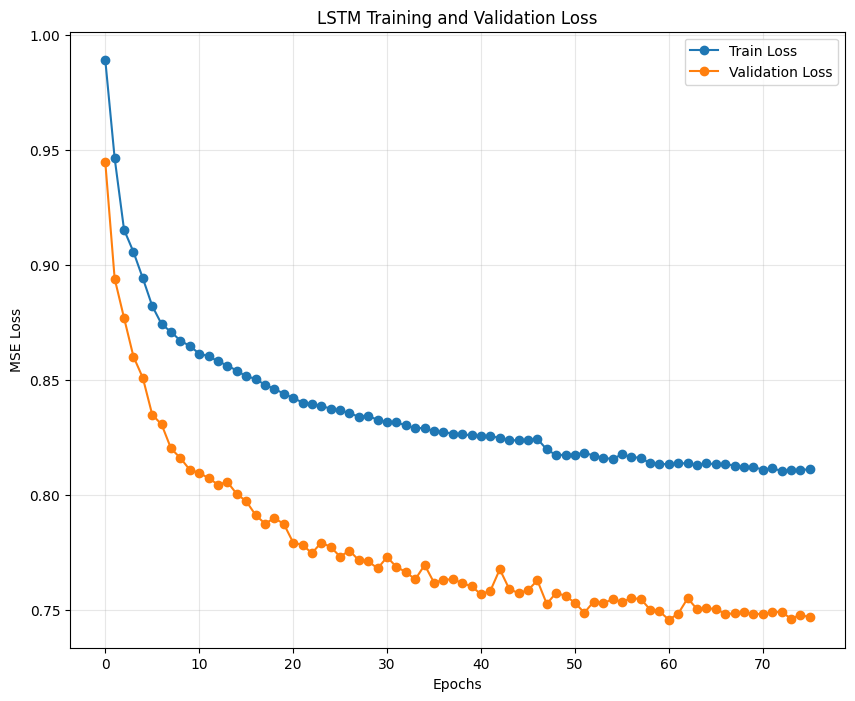

Best Val Loss: 0.7458 at epoch 61


In [ ]:
plt.figure(figsize = (10, 8))
plt.plot(train_losses, label = "Train Loss", marker = "o")
plt.plot(val_losses, label = "Validation Loss", marker = "o")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

print(f"Best Val Loss: {min(val_losses):.4f} at epoch {val_losses.index(min(val_losses)) + 1}")


## 7. Crash-Proof Final Evaluation
Extracting the final Mean Squared Error (MSE) and Pearson Correlation ($r$) on the unseen test data.

**RAM Optimization:** Because the ECoG dataset is massive, concatenating thousands of heavy PyTorch tensors at the end of the loop will instantly crash Colab's System RAM. We fix this by pushing the predictions to the CPU, converting them to lightweight NumPy arrays, and aggressively clearing the garbage collector (`gc.collect()`).

**Metric Calculation:**
Custom pure-NumPy math is used to calculate the Pearson Correlation to satisfy strict academic requirements against using external high-level ML libraries.

In [ ]:
import numpy as np
import gc

model.eval()

all_predictions = []
all_true_labels = []
total_test_loss = 0.0

print("Starting Final EEGNet Testing Phase...")

with torch.no_grad():
    for x_batch, y_batch in val_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        predictions = model(x_batch)

        batch_loss = criterion(predictions, y_batch)
        total_test_loss += batch_loss.item()

        # Convert immediately to lightweight NumPy arrays instead of keeping heavy PyTorch tensors
        all_predictions.append(predictions.cpu().numpy())
        all_true_labels.append(y_batch.cpu().numpy())

# --- CRITICAL MEMORY SAVER ---
# Delete the batch variables and force Python to clear the RAM before concatenating
del x_batch, y_batch, predictions
gc.collect()
torch.cuda.empty_cache()
# -----------------------------

final_mse = total_test_loss / len(val_loader)
print(f"\nFinal Result of Test MSE: {final_mse:.4f}")

# Use NumPy concatenate (much more memory efficient than torch.cat)
all_predictions = np.concatenate(all_predictions, axis=0)
all_true_labels = np.concatenate(all_true_labels, axis=0)

finger_names = ["Thumb", "Index", "Middle", "Ring", "Pinky"]
correlations = []

print("\n[Final Results] Pearson Correlations per Finger: ")

for i in range(5):
    pred_finger = all_predictions[:, i]
    true_finger = all_true_labels[:, i]

    # Standard NumPy Math
    pred_mean_diff = pred_finger - np.mean(pred_finger)
    true_mean_diff = true_finger - np.mean(true_finger)

    covariance = np.sum(pred_mean_diff * true_mean_diff)
    pred_var = np.sqrt(np.sum(pred_mean_diff ** 2))
    true_var = np.sqrt(np.sum(true_mean_diff ** 2))

    r = covariance / (pred_var * true_var + 1e-8)

    correlations.append(r)
    print(f" - {finger_names[i]}: {r:.4f}")

mean_correlation = sum(correlations) / 5
print(f"\nAverage Overall Correlations: {mean_correlation:.4f}")

Starting Final EEGNet Testing Phase...

Final Result of Test MSE: 0.7459

[Final Results] Pearson Correlations per Finger: 
 - Thumb: 0.6171
 - Index: 0.5003
 - Middle: 0.5038
 - Ring: 0.5748
 - Pinky: 0.5326

Average Overall Correlations: 0.5457
